# **Plotting STRING Score Distribution**

In [1]:
from pyXLMS import __version__

print(f"Installed pyXLMS version: {__version__}")

Installed pyXLMS version: 1.8.6


In [2]:
from pyXLMS import parser
from pyXLMS import plotting

All plotting functionality is available via the `plotting` submodule. We also import the `parser` submodule here for reading result files.

In [3]:
parser_result = parser.read(
    "../../data/ms_annika/Nucleus_Rep1_Crosslinks.parquet",
    engine="Custom",
    crosslinker="DSBSO",
)

Reading crosslinks...: 100%|██████████████████████████████████████████████████████████████████████████████████| 2937/2937 [00:00<00:00, 10267.12it/s]


We read crosslinks using the [generic parser](https://hgb-bin-proteomics.github.io/pyXLMS/pyXLMS.parser.html#pyXLMS.parser.read) from a single `.parquet` file. This file contains crosslinks validated for 1% estimated crosslink-level FDR from human K562 nuclei from [this study](https://doi.org/10.1038/s42004-025-01644-6).

Mapped 466 of 471 proteins (98.93842887473461%) to STRING IDs.


Annotating STRING scores for inter-links...: 100%|█████████████████████████████████████████████████████████████████████████| 382/382 [00:00<?, ?it/s]


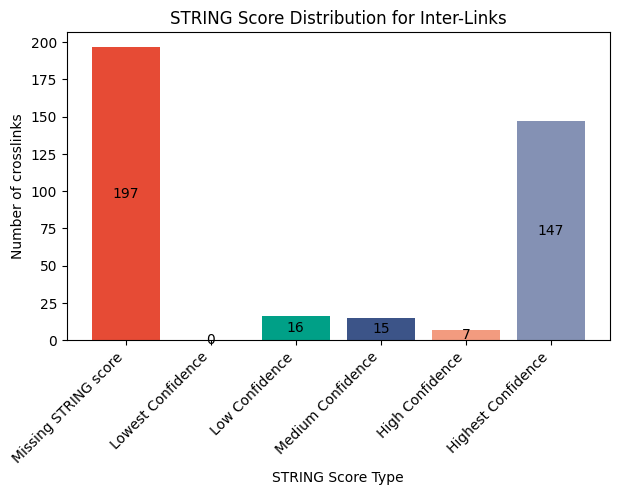

In [4]:
fig, ax = plotting.plot_string_score_distribution(
    data=parser_result["crosslinks"],
    organism="Homo sapiens",
    figsize=(7.0, 4.0),
    filename_prefix="string_score_dist_xls",
)

We can plot the STRING score distribution for our inter-link crosslinks by passing the crosslinks as the first argument. **Please note that plotting a STRING score distribution is only possible if all data have associated proteins, otherwise the function will raise a warning or an exception!** Because this function internally calls the STRING API we also need to specify an organism, e.g. in this case `"Homo sapiens"`. You can also specify the taxon identifier instead of the common name, which is actually the preferred way of passing the organism. You can find the taxon identifier of your organism [here](https://string-db.org/cgi/organisms). The default figure size is 16 by 9 inches and does not need to be set explicitly, we just used a smaller one here for demonstration purposes. The `filename_prefix` parameter is also optional, if it is given the plot is saved four times: once without the title in `.png` and `.svg` format, and once with the title in `.png` and `.svg` format.

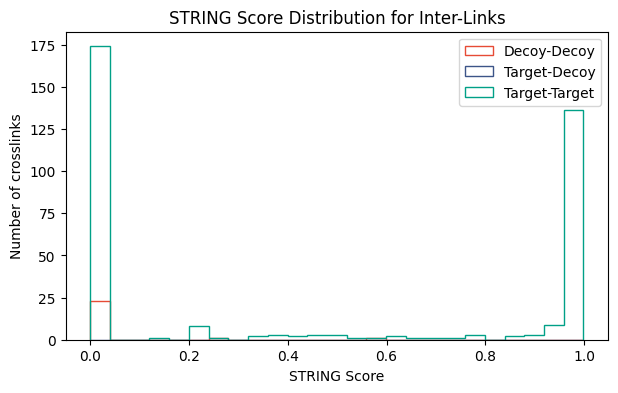

In [5]:
fig, ax = plotting.plot_string_score_distribution(
    data=parser_result["crosslinks"],
    plot_type="hist",
    figsize=(7.0, 4.0),
)

We can also plot the STRING score distribution as a histogram for target-target, target-decoy, and decoy-decoy hits by setting `plot_type="hist"`. Note that this time we also did not need to specify the organism because the crosslinks were already annotated with STRING scores from the previous function call. In general you can omit the organism if your data has been annotated with STRING scores previously, e.g. using `transform.annotate_string_scores()`. Since we did not specify a `filename_prefix` the plot is not saved to disk. There are also other parameters that can be set to tune your plot like `density` and `colors`, you can read more about all the possible parameters here: [**docs**](https://hgb-bin-proteomics.github.io/pyXLMS/pyXLMS.plotting.html#pyXLMS.plotting.plot_string_score_distribution.plot_string_score_distribution).

**It is generally recommended to call ``transform.annotate_string_scores()`` before using this function to preemptively catch errors during annotation!**